#week05 / DL_breast_cancer

컴퓨터공학과 / 202433638 / 장영환

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)

path = '/content/drive/MyDrive/Colab Notebooks/인공지능개론/week02/breast_cancer (1).csv'
df = pd.read_csv(path)

print("데이터 shape:", df.shape)
print(df.head())
print("\n컬럼별 데이터 타입:")
print(df.dtypes)
print("\n기본 통계:")
print(df.describe())
print("\n결측치 확인:")
print(df.isnull().sum())

데이터 shape: (569, 32)
   Unnamed: 0  mean radius  mean texture  mean perimeter  mean area  \
0           0        17.99         10.38          122.80     1001.0   
1           1        20.57         17.77          132.90     1326.0   
2           2        19.69         21.25          130.00     1203.0   
3           3        11.42         20.38           77.58      386.1   
4           4        20.29         14.34          135.10     1297.0   

   mean smoothness  mean compactness  mean concavity  mean concave points  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   mean symmetry  ...  worst texture  worst perimeter  worst area  \
0         0.2419  ..

Unnamed: 0은 데이터 식별용 인덱스성 컬럼으로 판단되어 입력 feature에서 제거

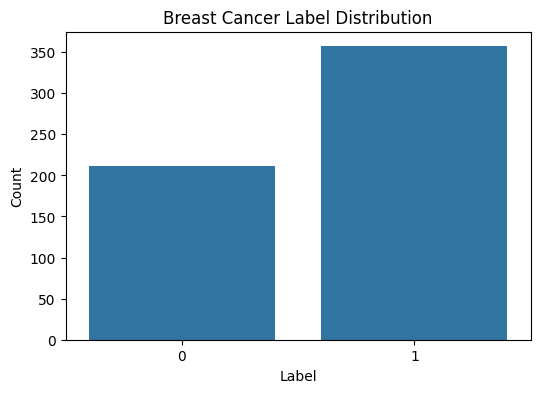

label 분포:
 label
0    212
1    357
Name: count, dtype: int64


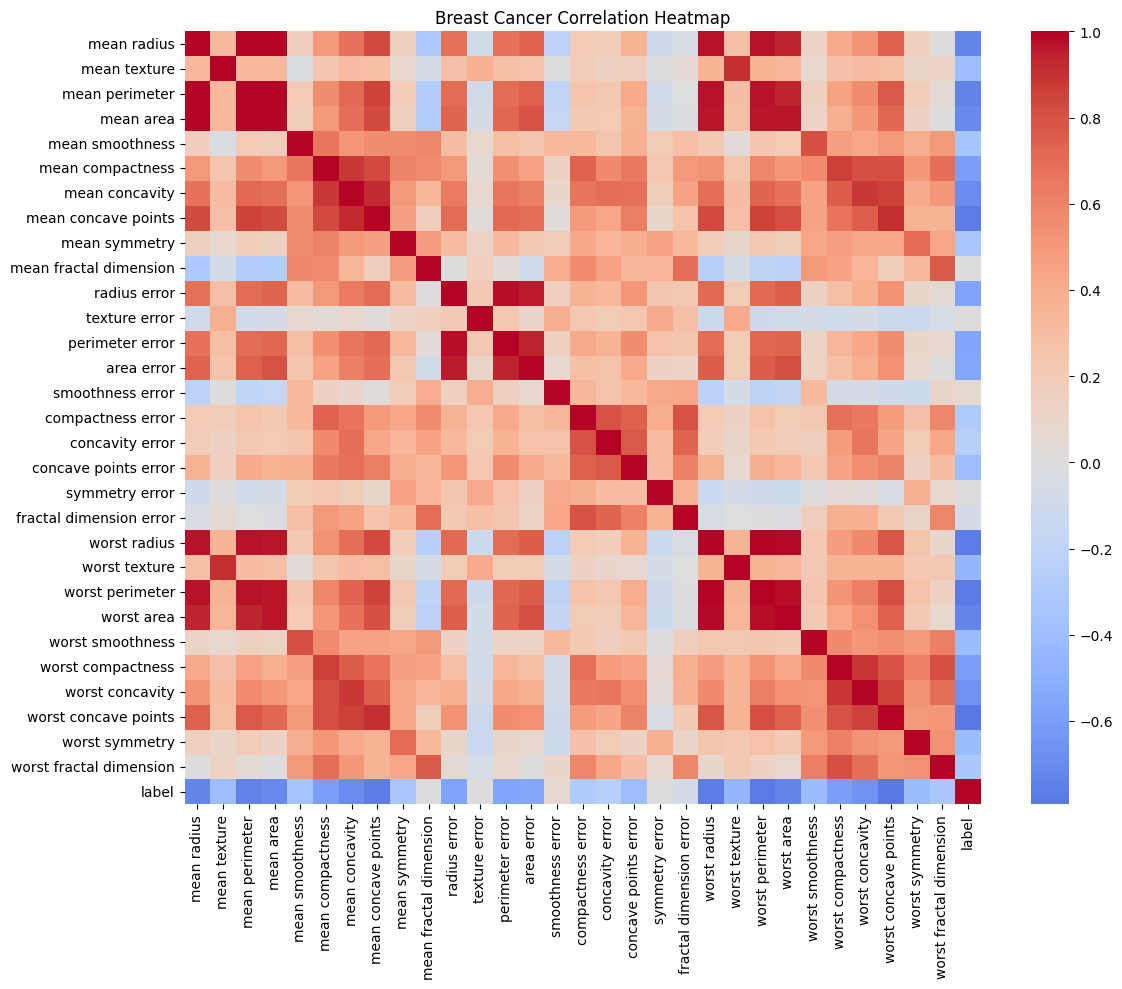

In [2]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label')
plt.title('Breast Cancer Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

print("label 분포:\n", df['label'].value_counts().sort_index())

plt.figure(figsize=(12, 10))
sns.heatmap(df.drop(columns=['Unnamed: 0']).corr(numeric_only=True),
            annot=False, cmap='coolwarm', center=0)
plt.title('Breast Cancer Correlation Heatmap')
plt.tight_layout()
plt.show()

#classification

label값 0, 1임으로 이진분류

학습 데이터: (455, 30), 테스트 데이터: (114, 30)
학습 레이블 분포:
label
0    170
1    285
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7253 - loss: 0.5449 - val_accuracy: 0.9011 - val_loss: 0.3613
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9093 - loss: 0.3159 - val_accuracy: 0.9451 - val_loss: 0.2168
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9368 - loss: 0.2067 - val_accuracy: 0.9341 - val_loss: 0.1634
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9533 - loss: 0.1427 - val_accuracy: 0.9451 - val_loss: 0.1321
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9643 - loss: 0.1185 - val_accuracy: 0.9560 - val_loss: 0.1005
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9835 - loss: 0.0858 - val_accuracy: 0.9560 - val_loss: 0.0937
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9698 - loss: 0.0930 - val_accuracy: 0.9560 - val_loss: 0.0891
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9753 - loss: 0.0741 - val_accuracy: 0.9560 - 

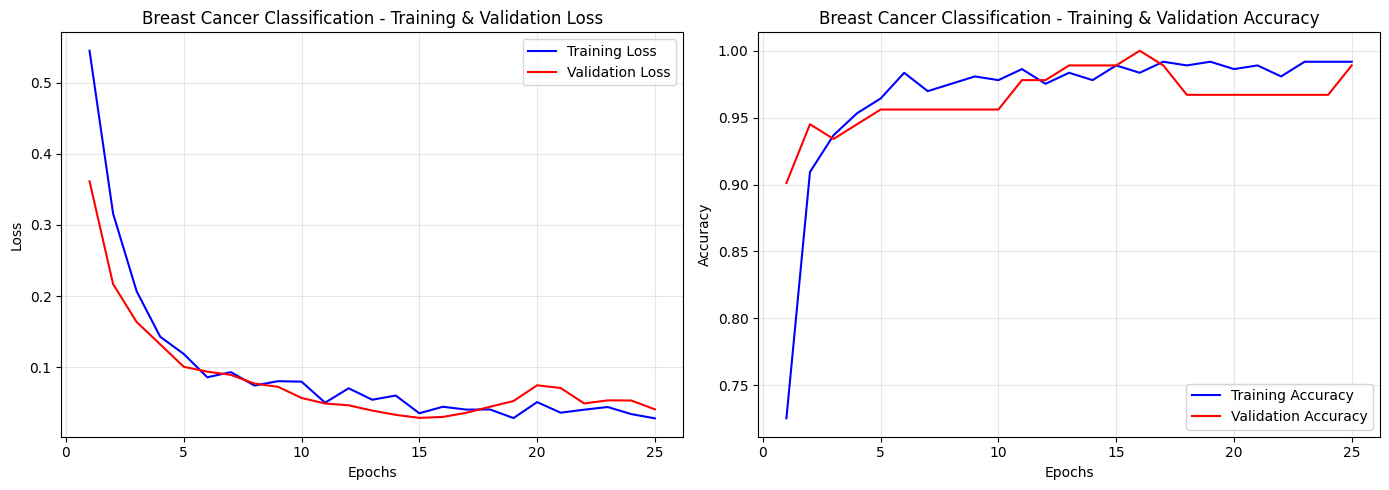

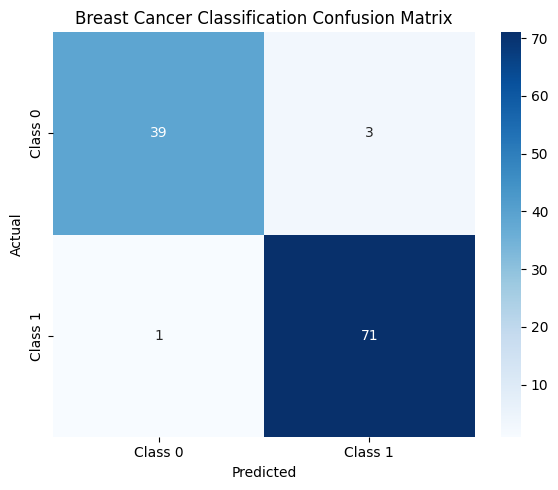

In [3]:
X_cls = df.drop(['Unnamed: 0', 'label'], axis=1)
y_cls = df['label']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=0, stratify=y_cls
)

scaler_cls = StandardScaler()
X_train_c = scaler_cls.fit_transform(X_train_c)
X_test_c = scaler_cls.transform(X_test_c)

print(f"학습 데이터: {X_train_c.shape}, 테스트 데이터: {X_test_c.shape}")
print(f"학습 레이블 분포:\n{pd.Series(y_train_c).value_counts().sort_index()}")

model_cls = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_c.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_cls.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_cls.summary()

early_stop_cls = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history_cls = model_cls.fit(
    X_train_c, y_train_c,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop_cls],
    verbose=1
)

y_pred_c = model_cls.predict(X_test_c)
y_pred_class_c = (y_pred_c > 0.5).astype(int).flatten()

print("\nClassification Report:")
print(classification_report(
    y_test_c, y_pred_class_c,
    target_names=['Class 0', 'Class 1']
))

cm = confusion_matrix(y_test_c, y_pred_class_c)
print("Confusion Matrix:")
print(cm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_cls = range(1, len(history_cls.history['loss']) + 1)

axes[0].plot(epochs_cls, history_cls.history['loss'], 'b-', label='Training Loss')
axes[0].plot(epochs_cls, history_cls.history['val_loss'], 'r-', label='Validation Loss')
axes[0].set_title('Breast Cancer Classification - Training & Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_cls, history_cls.history['accuracy'], 'b-', label='Training Accuracy')
axes[1].plot(epochs_cls, history_cls.history['val_accuracy'], 'r-', label='Validation Accuracy')
axes[1].set_title('Breast Cancer Classification - Training & Validation Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.title('Breast Cancer Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

#regression

학습 데이터: (455, 29), 테스트 데이터: (114, 29)
mean radius 통계:
count    569.000000
mean      14.127292
std        3.524049
min        6.981000
25%       11.700000
50%       13.370000
75%       15.780000
max       28.110000
Name: mean radius, dtype: float64


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,545 (17.75 KB)

 Trainable params: 4,545 (17.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 146.9701 - mae: 11.6115 - val_loss: 120.4119 - val_mae: 10.4117
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 67.9081 - mae: 7.2744 - val_loss: 43.5068 - val_mae: 5.5586
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 39.5686 - mae: 5.0140 - val_loss: 38.0555 - val_mae: 4.9662
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 30.4233 - mae: 4.3118 - val_loss: 30.9437 - val_mae: 4.5565
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 25.2595 - mae: 4.0819 - val_loss: 27.2762 - val_mae: 4.3021
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 26.3794 - mae: 4.0673 - val_loss: 21.9292 - val_mae: 3.7889
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 17.0921 - mae: 3.3840 - val_loss: 21.5501 - val_mae: 3.5794
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 17.1084 - mae: 3.2548 - val_loss: 17.8694 - val_mae: 3.3328
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5

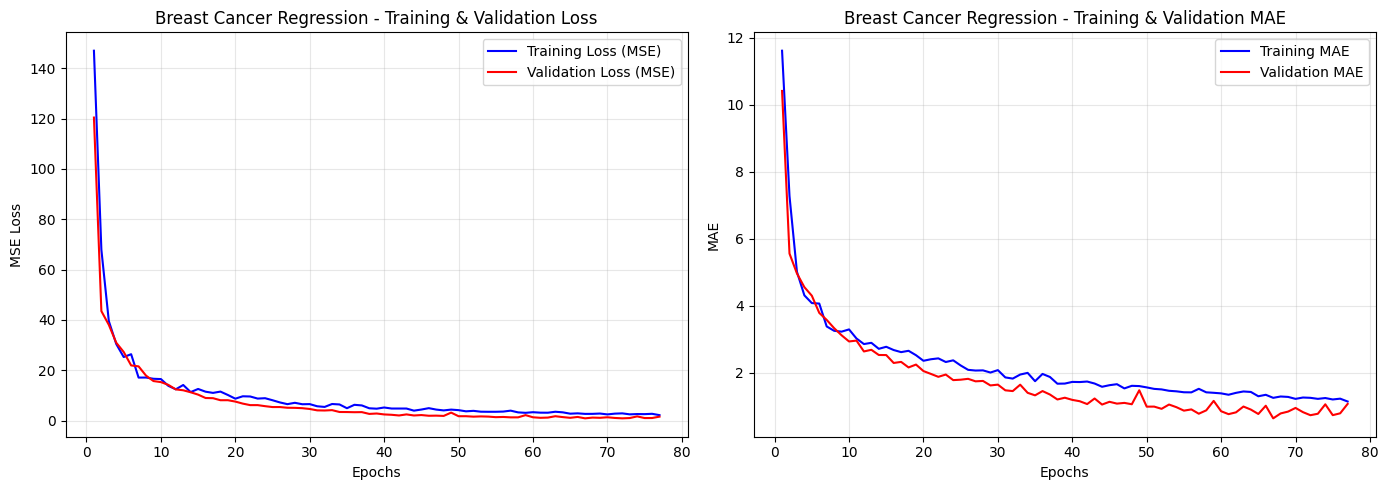

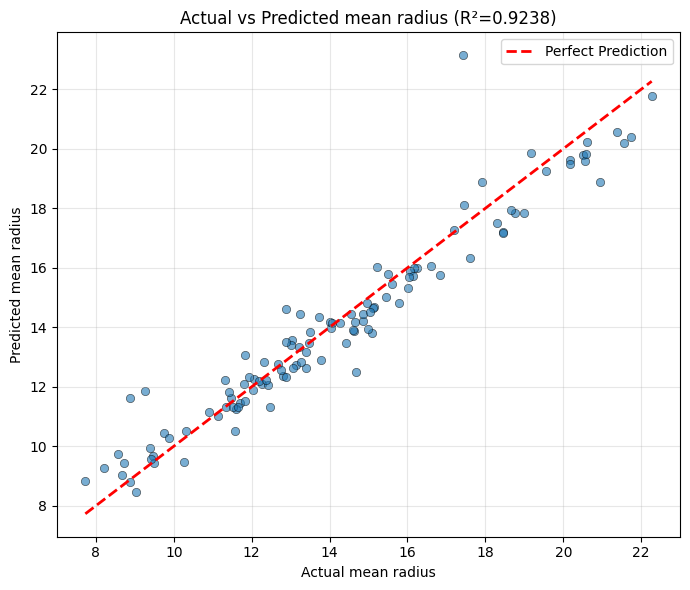

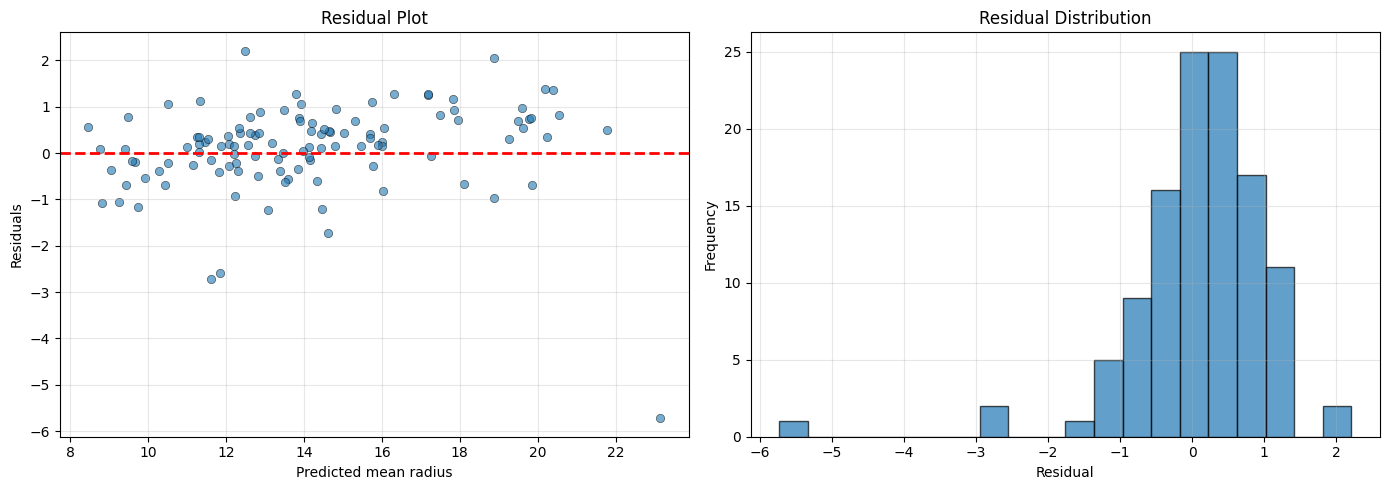

In [4]:
X_reg = df.drop(['Unnamed: 0', 'label', 'mean radius'], axis=1)
y_reg = df['mean radius']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=0
)

scaler_reg = StandardScaler()
X_train_r = scaler_reg.fit_transform(X_train_r)
X_test_r = scaler_reg.transform(X_test_r)

print(f"학습 데이터: {X_train_r.shape}, 테스트 데이터: {X_test_r.shape}")
print(f"mean radius 통계:\n{y_reg.describe()}")

model_reg = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_r.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model_reg.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model_reg.summary()

early_stop_reg = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history_reg = model_reg.fit(
    X_train_r, y_train_r,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop_reg],
    verbose=1
)

y_pred_r = model_reg.predict(X_test_r).flatten()

mse = mean_squared_error(y_test_r, y_pred_r)
mae = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_r, y_pred_r)

print("\nRegression Evaluation Metrics:")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  R²   : {r2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_reg = range(1, len(history_reg.history['loss']) + 1)

axes[0].plot(epochs_reg, history_reg.history['loss'], 'b-', label='Training Loss (MSE)')
axes[0].plot(epochs_reg, history_reg.history['val_loss'], 'r-', label='Validation Loss (MSE)')
axes[0].set_title('Breast Cancer Regression - Training & Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_reg, history_reg.history['mae'], 'b-', label='Training MAE')
axes[1].plot(epochs_reg, history_reg.history['val_mae'], 'r-', label='Validation MAE')
axes[1].set_title('Breast Cancer Regression - Training & Validation MAE')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(y_test_r, y_pred_r, alpha=0.6, edgecolors='k', linewidths=0.5)
plt.plot([y_test_r.min(), y_test_r.max()],
         [y_test_r.min(), y_test_r.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual mean radius')
plt.ylabel('Predicted mean radius')
plt.title(f'Actual vs Predicted mean radius (R²={r2:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

residuals = y_test_r - y_pred_r

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_r, residuals, alpha=0.6, edgecolors='k', linewidths=0.5)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted mean radius')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot')
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()